#Feature Selection

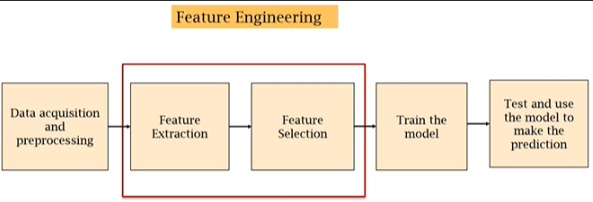

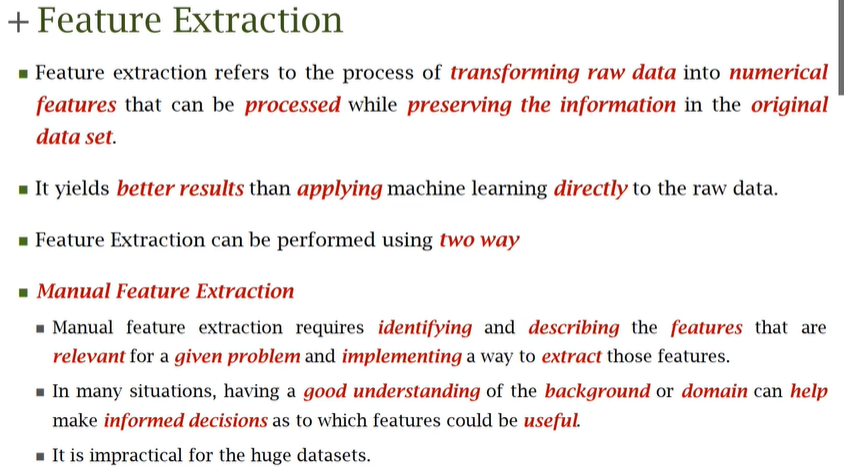

#Feature Selection = Varaible Selection = Attribute Selection = Dimensionality Reduction

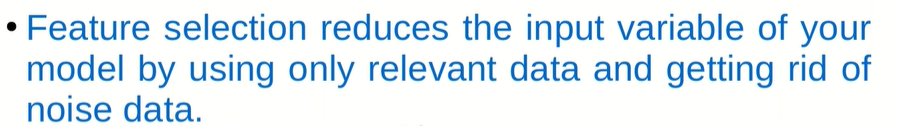

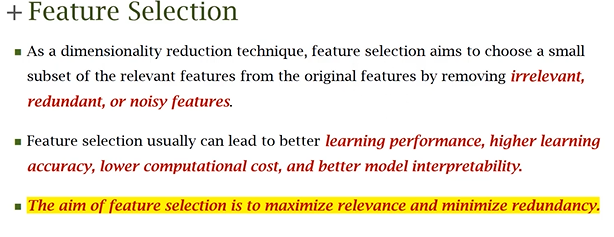

F.S : Process of Reducing the number of features to build the model with the goal of keeping only the best information

#types of Feature Selection Method

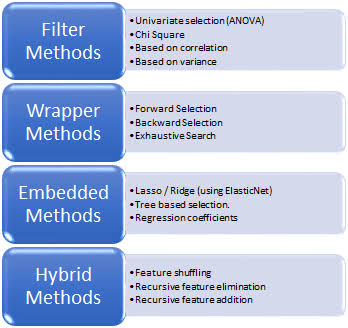

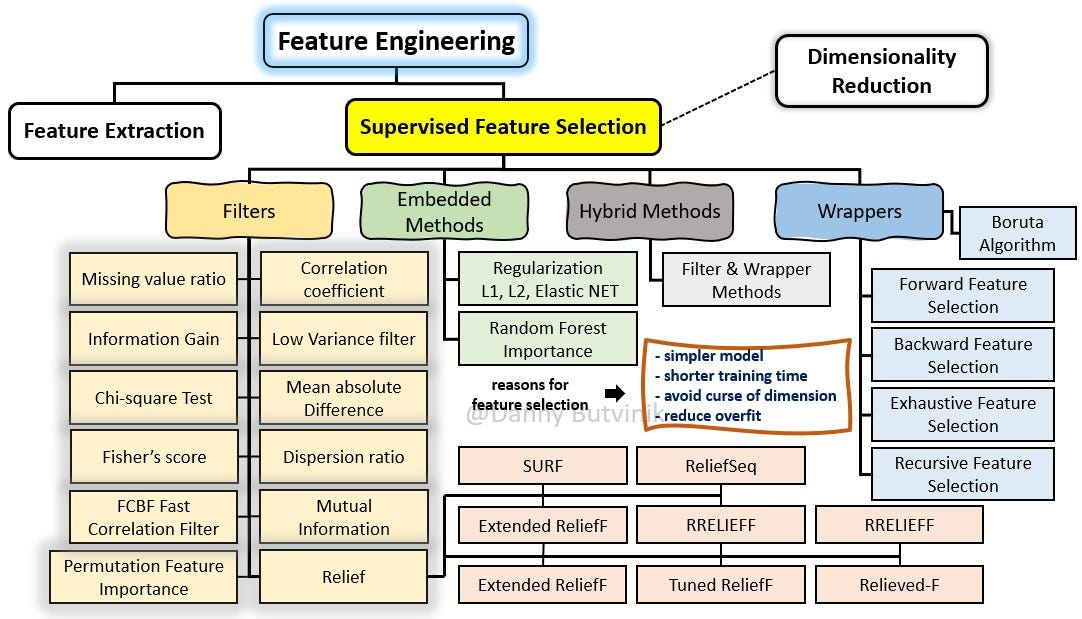

#Filter Methods

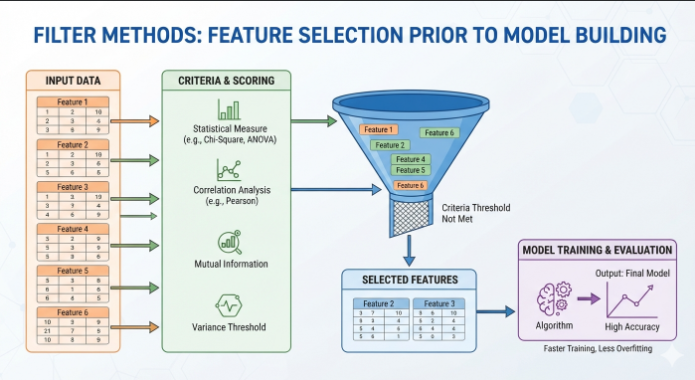

1-Variance Threshold

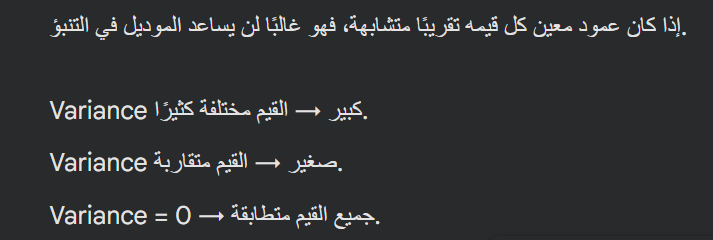

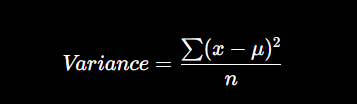

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel("/content/F_S.xlsx")

In [ ]:
df['married']=0

In [ ]:
df

,Age,Salary,City,Gender,buy,married
0,25,3000,0,0,1,0
1,45,9000,1,1,1,0
2,22,2500,0,0,0,0
3,55,12000,2,1,1,0
4,23,3500,0,0,1,0
5,42,9500,1,1,1,0
6,24,2400,0,0,0,0
7,54,13000,2,1,1,0
8,21,3000,0,0,1,0
9,44,9450,1,1,1,0


In [ ]:
x=df[['Age'	,'Salary',	'City',	'Gender','married']]
y=df['buy']

In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
selector=VarianceThreshold(threshold=0)

In [ ]:
selector.fit_transform(x)

array([[   25,  3000,     0,     0],
       [   45,  9000,     1,     1],
       [   22,  2500,     0,     0],
       [   55, 12000,     2,     1],
       [   23,  3500,     0,     0],
       [   42,  9500,     1,     1],
       [   24,  2400,     0,     0],
       [   54, 13000,     2,     1],
       [   21,  3000,     0,     0],
       [   44,  9450,     1,     1],
       [   20,  2350,     0,     0],
       [   53, 12000,     2,     1],
       [   26,  3000,     0,     0],
       [   41, 10500,     1,     1],
       [   27,  1900,     0,     0],
       [   56, 14000,     2,     1]])

In [ ]:
x.columns[selector.get_support()]

Index(['Age', 'Salary', 'City', 'Gender'], dtype='object')

#2-Correlation

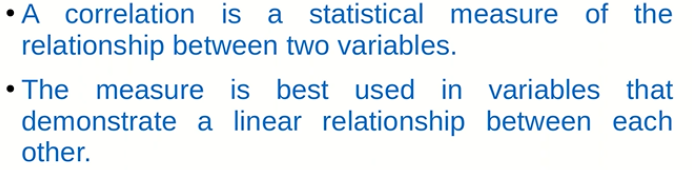

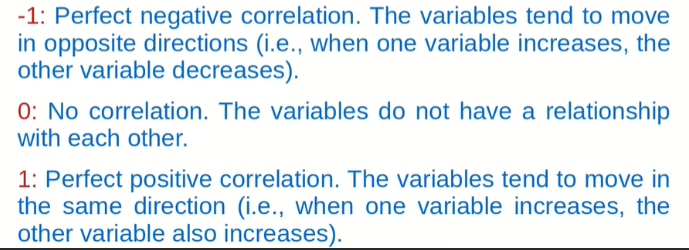

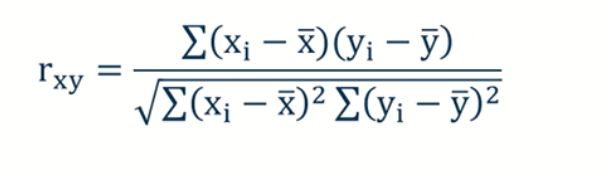

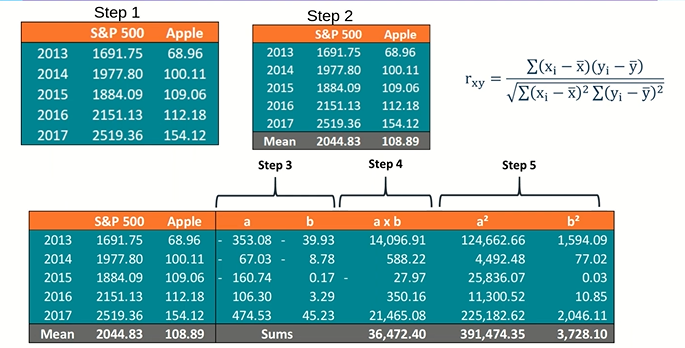

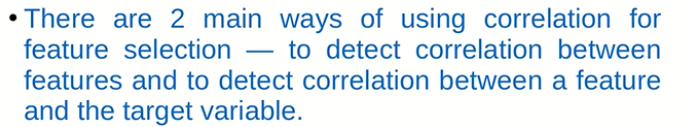

##1-Correlation between the features

corr between 2 features : high

then keeping just one feature to be used in the model

because the provide duplicate information

##2-Correlation between Features & target (Regression)

In [ ]:
df=pd.read_excel("/content/my_data.xlsx")

In [ ]:
df

,Home_NUM,Area,Bedrooms,Age_of_Home,Price
0,1,1850,3,12,345000
1,2,1200,2,25,215500
2,3,3200,4,5,610750
3,4,1500,3,18,280900
4,5,2100,3,10,395000
5,6,980,2,30,185000
6,7,2750,4,8,520300
7,8,1600,3,20,295600
8,9,2400,4,15,455000
9,10,1100,2,28,205400


In [ ]:
corr = df.corr(method='pearson')

corr["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Area,0.998190
Bedrooms,0.949164
Home_NUM,0.154744
Age_of_Home,-0.934260


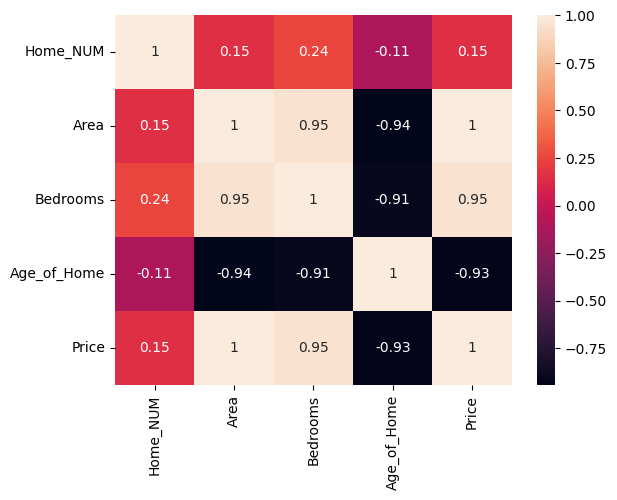

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
corr = df.corr(method='pearson')

In [ ]:
corr

,Home_NUM,Area,Bedrooms,Age_of_Home,Price
Home_NUM,1.000000,0.151126,0.243914,-0.110787,0.154744
Area,0.151126,1.000000,0.947820,-0.944455,0.998190
Bedrooms,0.243914,0.947820,1.000000,-0.911827,0.949164
Age_of_Home,-0.110787,-0.944455,-0.911827,1.000000,-0.934260
Price,0.154744,0.998190,0.949164,-0.934260,1.000000


###SelectKbest

feature selection method used in ML to select top 'k' features based on statistical equ

selectkBest depend on scoring function

###Scoring Functions
For Classification
1. chi2 (Chi-Square Test)
2. f_classif (ANOVA F-value)
3. mutual_info_classif (Mutual Information)


For Regression



1. f_regression (ANOVA F-value for Regression)
2. mutual_info_regression (Mutual Information for Regression)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    cross_val_score,
    learning_curve,
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
df=pd.read_csv("/content/students.csv",sep=';')
df.head()

X = df.drop("Target", axis=1)
y = df["Target"]


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

Scalar=MinMaxScaler()
X_scaled = Scalar.fit_transform(X)

Chi-square : statistical equation get the correlation between features & target

In [ ]:
selectKbest=SelectKBest(chi2,k=10)
x=selectKbest.fit_transform(X_scaled,y)
x.shape

(4424, 10)

In [ ]:
X.columns[selectKbest.get_support()].to_list()

['Application mode',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)']

-----------

#2-SelectPercentile

select the top 30% features

In [ ]:
from sklearn.feature_selection import SelectPercentile

selector = SelectPercentile(
    score_func=chi2,
    percentile=20
)

x=selector.fit_transform(X_scaled,y)
x.shape

(4424, 7)

In [ ]:
X.columns[selector.get_support()].to_list()

['Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Curricular units 1st sem (grade)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)']

#3- Recursive Feature Elimination (RFE)

train la el model , and use the model to select the features

##Steps
1. Train model on all the dataset



2. Rank the importance of each feature
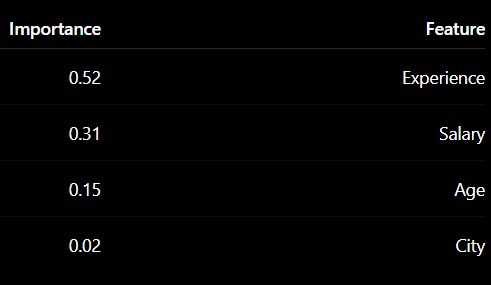

3. Delete the col with lowest importance

4.Train the model  on all the data (after removeing)

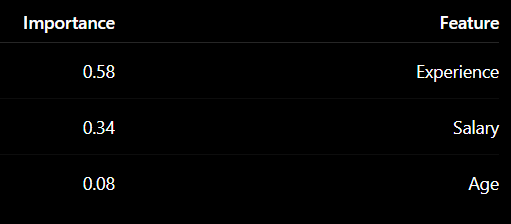

importance of the feature different from model to another

1. linear regression - coefficients
2. random forest & decision tree - feature importance
3. logistics regression - coefficients



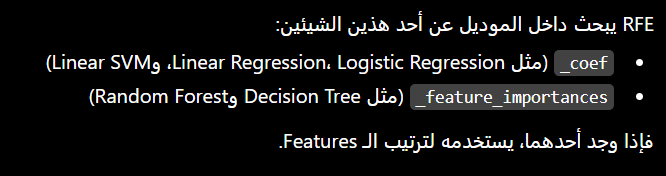

all Features

      │
      ▼

Train Model

      │
      ▼

Features Importance

      │
      ▼

RFE delete lowest Feature

      │
      ▼

Train model

      │
      ▼

Feature Importance

      │
      ▼

delete Feature

      │
      ▼

repeat until get the Req.number

In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Read data
df = pd.read_csv("/content/students.csv", sep=";")

# Features & Target
X = df.drop("Target", axis=1)
y = df["Target"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,

)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
rfe=RFE(model,n_features_to_select=10)
x=rfe.fit_transform(X_train,y_train)
y_pred=rfe.predict(X_test)

In [ ]:
rfe.estimator_.feature_importances_

array([0.07564529, 0.07894554, 0.06344432, 0.09631971, 0.07473837,
       0.12173017, 0.09897528, 0.06616981, 0.19550517, 0.12852632])

In [ ]:
#to know the columns selected
selected_features = X_train.columns[rfe.get_support()]

print(selected_features.to_list())

['Course', 'Previous qualification (grade)', "Father's occupation", 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']


------------

#4- RFECV : Recursive Feature Elimination with Cross Validation

Badel ma ba7ddd 10 features

basiib el model hwa eli ya3ref law7do kam features homa eli mohmiin

6 Features




    6 Features

     │
     ▼

    Train (5 Folds)

     │
     ▼

    Average Accuracy = 90%

     │
     ▼

    Feature Importance

     │
     ▼
    Delete F
────────────────────────

    5 Features
     │
     ▼
    Train (5 Folds)
     │
     ▼
    Average Accuracy = 92%
     │
     ▼
    Feature Importance
     │
     ▼
    Delete E
────────────────────────

    4 Features
     │
     ▼
    Train (5 Folds)
     │
     ▼
    Average Accuracy = 95%
     │
     ▼
    Feature Importance
     │
     ▼
    Delete D

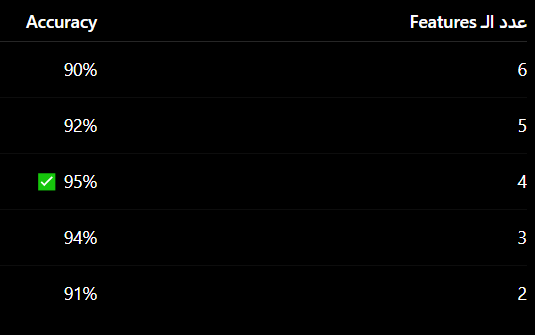

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)

selector = RFECV(
    estimator=model,
    step=1,
    cv=3,
    scoring="accuracy"
)

X_selected = selector.fit_transform(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
X_selected.shape

(3539, 20)

In [ ]:
#to know the columns selected
selected_features = X_train.columns[selector.get_support()]

print(selected_features.to_list())

['Marital status', 'Application order', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']


#5- Forward Feature Selection = Sequential Forward Selection (SFS)

##start without any feature then add one feature at each time

el lafa el 2ola :

[]

Trial 1

[A]

Accuracy = 70%

Trial 2

[B]

Accuracy = 82%

Trial 3

[C]

Accuracy = 75%

Trial 4

[D]

Accuracy = 68%

Trial 5

[E]

Accuracy = 80%

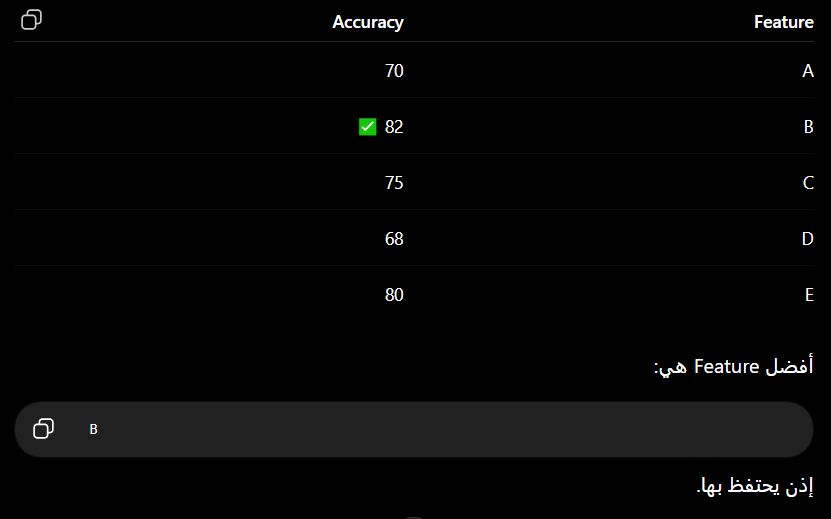


El lafa el tania

[B]

Trial 1

[B+A]

Accuracy = 84%

Trial 2

[B+C]

Accuracy = 90%

Trial 3

[B+D]

Accuracy = 83%

Trial 4

[B+E]

Accuracy = 87%

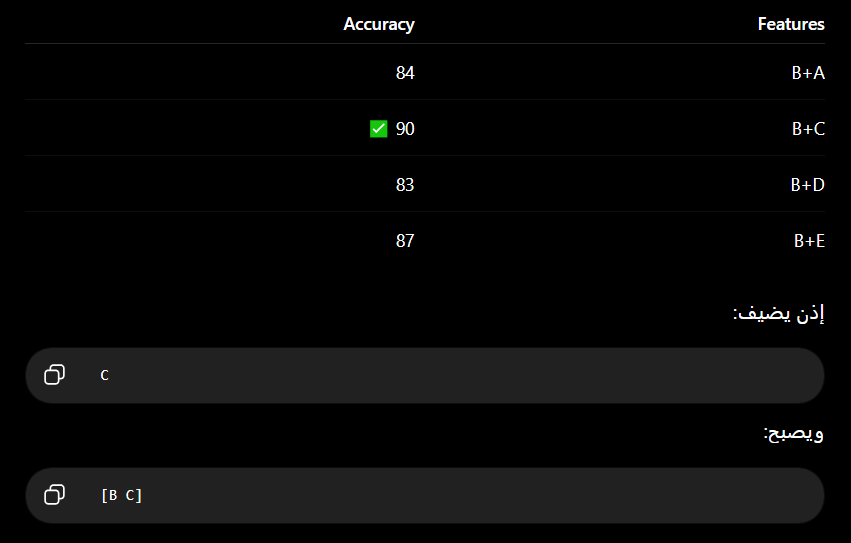

1. Selected = { }
2. try each feature individual
3. Selected = {add the best feature}
4. try per_feature + each Feature
5. add


In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)

ffs = SequentialFeatureSelector(
    model,
    k_features=5,
    forward=True,
    floating=False,
    scoring="accuracy",
    cv=5
)

ffs.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

SequentialFeatureSelector(estimator=LogisticRegression(max_iter=50),
                          k_features=(5, 5), scoring='accuracy')

In [ ]:
selected = list(ffs.k_feature_names_)
print(selected)

['Tuition fees up to date', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']


-------------------

#6- Backward Feature Selection (BFS) = Sequential Backward Selection (SBS)

El Lafa el 2ola

[A B C D E]

Trial 1

[B C D E]

Accuracy = 90%

Trial 2

[A C D E]

Accuracy = 85%

Trial 3

[A B  D E]

Accuracy = 93%


Trial 4

[A B C E]

Accuracy = 88%


Trial 5

[A B C D]

Accuracy = 91%


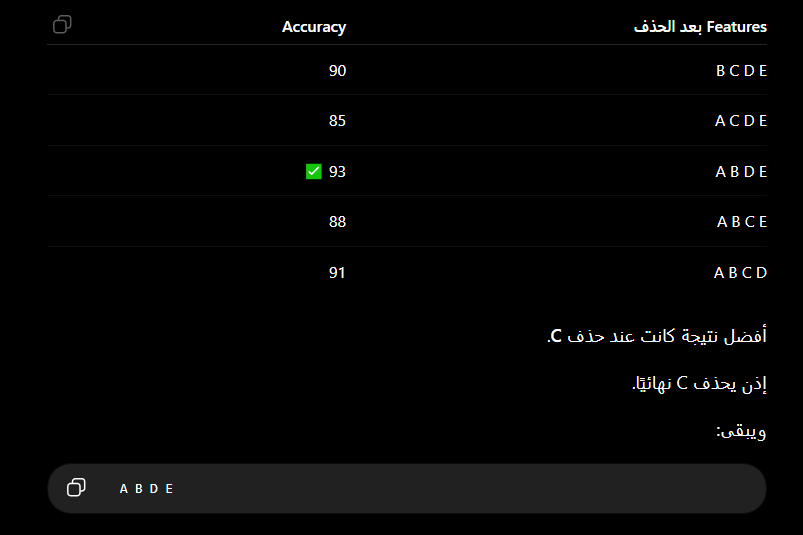

El Lafa El tania


[A B  D E]

Trial 1

[B D E]

Accuracy = 90%

Trial 2

[A D E]

Accuracy = 85%

Trial 3

[A B  D E]

Accuracy = 93%


Trial 4


[A B  D]

Accuracy = 91%


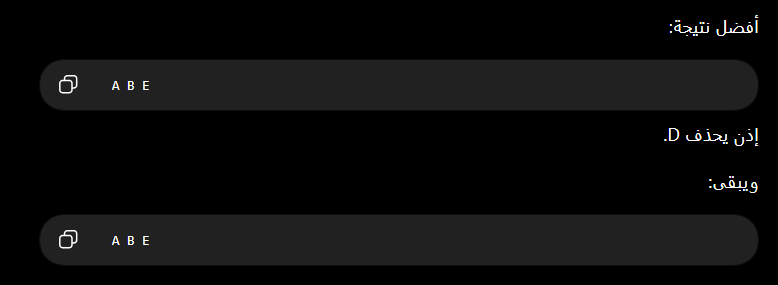

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)

bfs = SequentialFeatureSelector(
    model,
    k_features=3,
    forward=False,
    floating=False,
    scoring="accuracy",
    cv=2
)

bfs.fit(X, y)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/li

SequentialFeatureSelector(cv=2, estimator=LogisticRegression(max_iter=50),
                          forward=False, k_features=(3, 3), scoring='accuracy')

In [ ]:
selected = list(bfs.k_feature_idx_)
print(selected)

[16, 28, 30]


In [ ]:
selected = list(bfs.k_feature_names_)
print(selected)

['Tuition fees up to date', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']


--------------------------

#7- Select From Model (SFM)

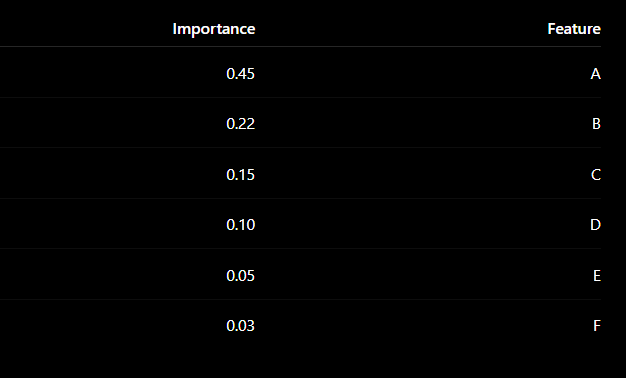

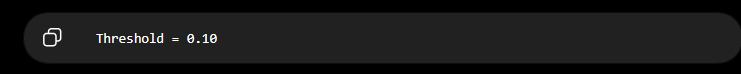

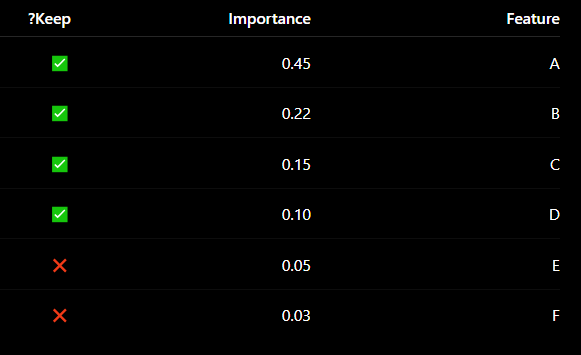

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

selector = SelectFromModel(
    estimator=model,
    threshold="mean"
)

selector.fit(X, y)

SelectFromModel(estimator=RandomForestClassifier(), threshold='mean')

In [ ]:
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['Course', 'Previous qualification (grade)', 'Father's occupation',
       'Admission grade', 'Tuition fees up to date', 'Age at enrollment',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'],
      dtype='object')


#Summary

Filter method

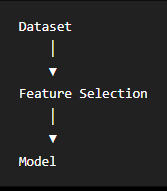

1. don't depend on the model

2. depend on only statistics

3. v.fast

4. good. with large DS

5. don't need training

6. reduce training time

7. may be delete important feature

2-Wrapper Methods

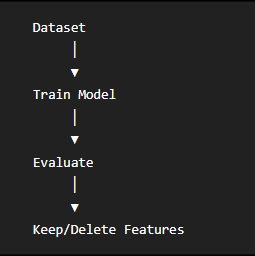

1. depend on model
2. v.slow ( training many times)
3. medium DS
4. best accuracy

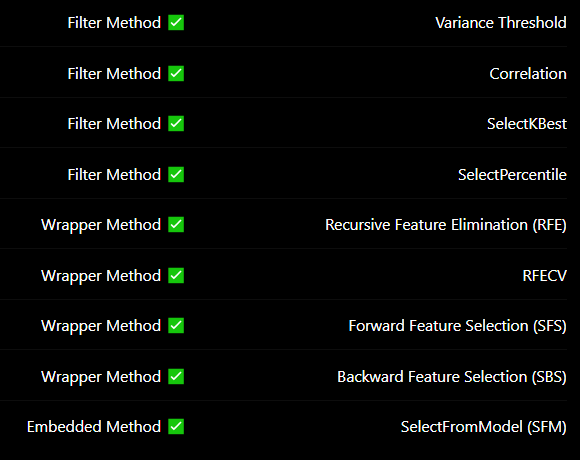

3-Embedded Methods

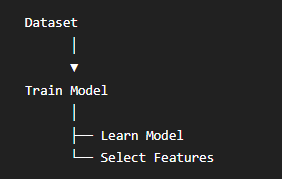

1. faster than wrapper
2. better accuracy than filter
3. model nafso hwa eli select features
4. work only with models support coefficients | feature importance
    1. Random Forest
    2. Decision Tree
    3. XGBoost
    4. Logistic Regression




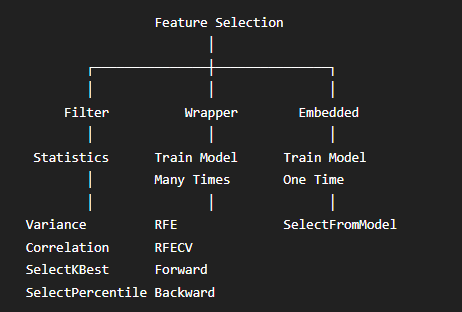